In [1]:
import os
from pathlib import Path

PROJECT_DIR = Path(os.getenv('PROJECT_DIR'))
os.makedirs(PROJECT_DIR / 'paper/figures/subject_leakage', exist_ok=True)

In [2]:
import mlflow
client = mlflow.tracking.MlflowClient()

all_runs = mlflow.search_runs(search_all_experiments=True).sort_values('start_time')

In [3]:
all_runs['subject_leakage'] = all_runs['params.data_leakage'].apply(lambda x: x == 'True')
all_runs['subject_leakage'] = all_runs['subject_leakage'].astype('category')

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Liberation Sans'
plt.rcParams['text.usetex'] = True
plt.rc('text.latex', preamble=r'''
\usepackage{amsmath} 
\usepackage{helvet} 
\renewcommand{\familydefault}{\sfdefault}
''')
plt.rcParams.update({'font.size': 10})

from scipy.stats import ttest_rel, wilcoxon, shapiro
from itertools import combinations


def cohens_d_paired(x, y):
    diffs = x.values - y.values
    return diffs.mean() / diffs.std(ddof=1)


def plot_grouped_boxplot_with_significance(
    df: pd.DataFrame,
    group_col: str,
    target_col: str,
    y_range: int | float,
    title: str = '',
    xlabel: str = '',
    ylabel: str = '',
    distinct_significance: bool = False,
    save_path: str | None = None,
    figsize: tuple[int, int] = (8, 4),
    invert_xaxis: bool = True,
    ax=None,
):
    # define significance level thresholds
    def get_star_annotation(p, cohens_d, diff):
        # prepare suffix
        p_str = f'{p:.2e}'.split('e')
        p_str = p_str[0] + '\\mathrm{e}{' + ('-' if p_str[1].startswith('-') else '') + p_str[1].lstrip('-0') + '}'
        suffix = f' ($p={p_str}$, Cohen\'s $d=\\mathrm{{{cohens_d:.2f}}}$, $\\Delta={diff:.3f}$)'
        
        if p < 0.05 and distinct_significance:
            if p < 0.001:
                return '***' + suffix
            elif p < 0.01:
                return '**' + suffix
            else:
                return '*' + suffix
        elif p < 0.05:
            return suffix[2:-1]
            
        return ''
    
    unique_groups = sorted(df[group_col].cat.categories, reverse=True)

    # create the boxplot
    if figsize is not None:
        plt.figure(figsize=figsize)
    if ax is None:
        ax = sns.boxplot(
            x=group_col, y=target_col,
            data=df[df[target_col] > -1],  # HARDCODED OUTLIER REMOVAL
            hue=group_col, order=sorted(unique_groups))
    else:
        sns.boxplot(
            x=group_col, y=target_col,
            data=df[df[target_col] > -1],  # HARDCODED OUTLIER REMOVAL
            hue=group_col, ax=ax, order=sorted(unique_groups)
        )
    
    # perform pairwise t-tests and collect significant pairs
    y_max = df[target_col].max()
    y_offset = y_range * 0.15
    significance_annotations = []

    for i, (group1, group2) in enumerate(combinations(unique_groups, 2)):
        data1 = df[df[group_col] == group1][target_col]
        data2 = df[df[group_col] == group2][target_col]

        # t-test/wilcoxon based on diffs normality
        diffs = data1.values - data2.values
        _, shapiro_p = shapiro(diffs)
        if shapiro_p > 0.05:
            stat, p_val = ttest_rel(data1, data2)  # use t-test
        else:
            stat, p_val = wilcoxon(data1, data2)  # use wilcoxon

        # effect size
        d = cohens_d_paired(data1, data2)  # Cohen's d
        diff = abs(data1.mean() - data2.mean())

        stars = get_star_annotation(p_val, d, diff)
        if stars:
            x1, x2 = unique_groups.index(group1), unique_groups.index(group2)
            y = y_max + y_offset * (len(significance_annotations) + 1)

            y_scale_param = y_range * 0.03
            ax.plot([x1, x1, x2, x2], [y, y+y_scale_param, y+y_scale_param, y], lw=1, c='black')
            ax.text(
                (x1+x2)*.5,
                y+2.5*y_scale_param,
                stars,
                ha='center', va='bottom', color='black',
                bbox=dict(facecolor='white', edgecolor='none'),
                fontsize=8
            )
            
            significance_annotations.append((group1, group2, stars))

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if invert_xaxis:
        ax.invert_xaxis()
    sns.despine()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)
        
    return significance_annotations

In [5]:
LATEX_LINEWIDTH = 500.484 / 72.27

### R-squared

In [6]:
import scipy.stats as stats

# val
leakage = all_runs[all_runs['subject_leakage'] == True]['metrics.val_r2_epoch']
no_leakage = all_runs[all_runs['subject_leakage'] == False]['metrics.val_r2_epoch']
diffs = leakage.values - no_leakage.values
stat, p = stats.shapiro(diffs)
print(f'[val]  Shapiro-Wilk: W={stat:.3f}, p={p:.3g}')

# test
leakage = all_runs[all_runs['subject_leakage'] == True]['metrics.test_r2_epoch']
no_leakage = all_runs[all_runs['subject_leakage'] == False]['metrics.test_r2_epoch']
diffs = leakage.values - no_leakage.values
stat, p = stats.shapiro(diffs)
print(f'[test] Shapiro-Wilk: W={stat:.3f}, p={p:.3g}')

[val]  Shapiro-Wilk: W=0.763, p=5.87e-05
[test] Shapiro-Wilk: W=0.943, p=0.177


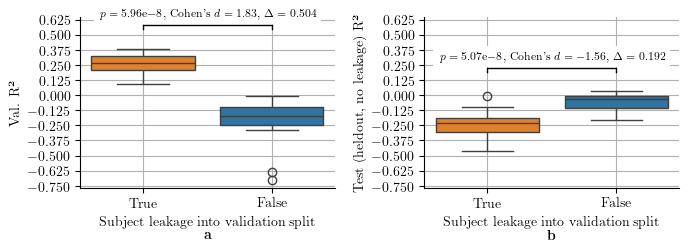

In [7]:
from matplotlib.ticker import MultipleLocator

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
fig.set_figheight(LATEX_LINEWIDTH * 3 / 9)
fig.set_figwidth(LATEX_LINEWIDTH)

label = 'Subject leakage into validation split'
removed_outlier = all_runs[all_runs['metrics.val_r2_epoch'] > -1]  # HARDCODED PART
y_range = removed_outlier['metrics.val_r2_epoch'].max() - removed_outlier['metrics.val_r2_epoch'].min()

# left plot
plot_grouped_boxplot_with_significance(
    all_runs,
    group_col='subject_leakage',
    target_col='metrics.val_r2_epoch',
    y_range=y_range,
    ylabel='Val. R²',
    figsize=None,
    ax=ax1,
)

# right plot
plot_grouped_boxplot_with_significance(
    all_runs,
    group_col='subject_leakage',
    target_col='metrics.test_r2_epoch',
    y_range=y_range,
    ylabel='Test (heldout, no leakage) R²',
    figsize=None,
    ax=ax2,
)

# customize left plot
ax1.grid()
ax1.get_legend().remove()
ax1.set_xlabel(f'{label}\n$\\bf{{a}}$')

# customize right plot
ax2.grid()
ax2.yaxis.get_label().set_visible(True)
ax2.yaxis.set_tick_params(labelleft=True)
ax2.get_legend().remove()
ax2.set_xlabel(f'{label}\n$\\bf{{b}}$')

ticks = ax1.get_yticks()
step = ticks[1] - ticks[0]
ax1.yaxis.set_major_locator(MultipleLocator(step / 2))

plt.subplots_adjust(wspace=0.35)
plt.savefig(PROJECT_DIR / 'paper/figures/subject_leakage/00-r2.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [8]:
label = 'r2'
caption = 'Impact of the subject leakage into validation split on $R^2$ metric.'

# aggregate results
agg = all_runs[['subject_leakage', 'metrics.val_r2_epoch', 'metrics.test_r2_epoch']].groupby('subject_leakage').aggregate(
    lambda x: f'${x.mean():.3f} \\pm {x.std():.3f}$'
)

# format tabular
latex = agg.to_latex()
latex = latex.replace(
    'subject_leakage',
    'Subject leakage into\nvalidation split'
).replace(
    'metrics.val_r2_epoch',
    'Val. $R^2$'
).replace(
    'metrics.test_r2_epoch',
    'Test (heldout, no leakage) $R^2$'
)

# format table
latex = f"""\
\\begin{{table}}
\\centering
\\caption{{{caption}}}
\\label{{tab:{label}}}
{latex}\\end{{table}}
"""
print(latex)

\begin{table}
\centering
\caption{Impact of the subject leakage into validation split on $R^2$ metric.}
\label{tab:r2}
\begin{tabular}{lll}
\toprule
 & Val. $R^2$ & Test (heldout, no leakage) $R^2$ \\
Subject leakage into
validation split &  &  \\
\midrule
False & $-0.248 \pm 0.295$ & $-0.058 \pm 0.063$ \\
True & $0.256 \pm 0.083$ & $-0.250 \pm 0.108$ \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_2062/1508300741.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = all_runs[['subject_leakage', 'metrics.val_r2_epoch', 'metrics.test_r2_epoch']].groupby('subject_leakage').aggregate(


### MAE

In [9]:
import scipy.stats as stats

# val
leakage = all_runs[all_runs['subject_leakage'] == True]['metrics.val_mae_epoch']
no_leakage = all_runs[all_runs['subject_leakage'] == False]['metrics.val_mae_epoch']
diffs = leakage.values - no_leakage.values
stat, p = stats.shapiro(diffs)
print(f'[val]  Shapiro-Wilk: W={stat:.3f}, p={p:.3g}')

# test
leakage = all_runs[all_runs['subject_leakage'] == True]['metrics.test_mae_epoch']
no_leakage = all_runs[all_runs['subject_leakage'] == False]['metrics.test_mae_epoch']
diffs = leakage.values - no_leakage.values
stat, p = stats.shapiro(diffs)
print(f'[test] Shapiro-Wilk: W={stat:.3f}, p={p:.3g}')

[val]  Shapiro-Wilk: W=0.970, p=0.643
[test] Shapiro-Wilk: W=0.956, p=0.343


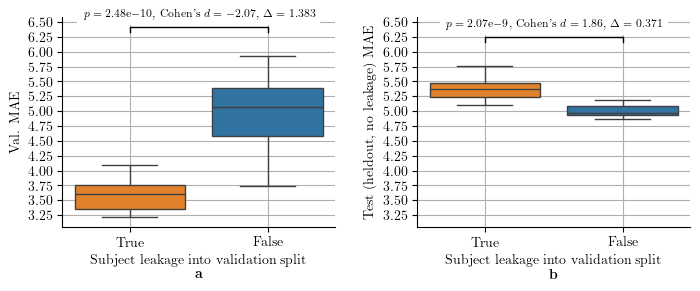

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
fig.set_figheight(LATEX_LINEWIDTH * 3.5 / 9)
fig.set_figwidth(LATEX_LINEWIDTH)

label = 'Subject leakage into validation split'
y_range = all_runs['metrics.val_mae_epoch'].max() - all_runs['metrics.val_mae_epoch'].min()

# left plot
plot_grouped_boxplot_with_significance(
    all_runs,
    group_col='subject_leakage',
    target_col='metrics.val_mae_epoch',
    y_range=y_range,
    ylabel='Val. MAE',
    figsize=None,
    ax=ax1,
)

# right plot
plot_grouped_boxplot_with_significance(
    all_runs,
    group_col='subject_leakage',
    target_col='metrics.test_mae_epoch',
    y_range=y_range,
    ylabel='Test (heldout, no leakage) MAE',
    figsize=None,
    ax=ax2,
)

# customize left plot
ax1.grid()
ax1.get_legend().remove()
ax1.set_xlabel(f'{label}\n$\\bf{{a}}$')

# customize right plot
ax2.grid()
ax2.yaxis.get_label().set_visible(True)
ax2.yaxis.set_tick_params(labelleft=True)
ax2.get_legend().remove()
ax2.set_xlabel(f'{label}\n$\\bf{{b}}$')

ticks = ax1.get_yticks()
step = ticks[1] - ticks[0]
ax1.yaxis.set_major_locator(MultipleLocator(step / 4))

plt.subplots_adjust(wspace=0.3)
plt.savefig(PROJECT_DIR / 'paper/figures/subject_leakage/01-mae.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [11]:
label = 'mae'
caption = 'Impact of the subject leakage into validation split on MAE metric.'

# aggregate results
agg = all_runs[['subject_leakage', 'metrics.val_mae_epoch', 'metrics.test_mae_epoch']].groupby('subject_leakage').aggregate(
    lambda x: f'${x.mean():.3f} \\pm {x.std():.3f}$'
)

# format tabular
latex = agg.to_latex()
latex = latex.replace(
    'subject_leakage',
    'Subject leakage into\nvalidation split'
).replace(
    'metrics.val_mae_epoch',
    'Val. MAE'
).replace(
    'metrics.test_mae_epoch',
    'Test (heldout, no leakage) MAE'
)

# format table
latex = f"""\
\\begin{{table}}
\\centering
\\caption{{{caption}}}
\\label{{tab:{label}}}
{latex}\\end{{table}}
"""
print(latex)

\begin{table}
\centering
\caption{Impact of the subject leakage into validation split on MAE metric.}
\label{tab:mae}
\begin{tabular}{lll}
\toprule
 & Val. MAE & Test (heldout, no leakage) MAE \\
Subject leakage into
validation split &  &  \\
\midrule
False & $4.978 \pm 0.571$ & $5.001 \pm 0.101$ \\
True & $3.595 \pm 0.269$ & $5.373 \pm 0.178$ \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_2062/2069663505.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = all_runs[['subject_leakage', 'metrics.val_mae_epoch', 'metrics.test_mae_epoch']].groupby('subject_leakage').aggregate(
